# Worksheet: Autoencoders

**Topic:** Autoencoders

## Learning goals

By the end of this worksheet, students should be able to:

1. Explain what an autoencoder does.
2. Distinguish the encoder, latent space, and decoder.
3. Explain the role of the bottleneck.
4. Compute and interpret reconstruction error.
5. Build a simple undercomplete autoencoder.
6. Explain sparse and denoising autoencoders.
7. Connect autoencoders to business uses such as anomaly detection and feature extraction.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---

# 1. What is an autoencoder?

An **autoencoder** is a neural network trained to reproduce its own input.

It learns two functions:

- **Encoder:** compresses the input. We call the encoder $h$. The encoder will take $x$ as input. The latent space $z = h(x)$. Ideally, $z$ is a lot smaller than $x$
- **Decoder:** reconstructs the input. We call the decoder $f$. The decoder will take an encode latent space $\tilde{x} = f(z)$

THe goal is to have the smallest difference between $x$ and $\tilde{x}$. The compressed representation $z$ is called the **latent space** or **bottleneck**. You could use $z$ as your data.

## Practice 1A

Fill in the blanks:

1. The part that compresses the input is the **_____**.
2. The compressed representation is called the **_____ space**.
3. The part that reconstructs the input is the **_____**.

**Your answers here:**  
1.  encoder
2.  latent
3.  decoder

## Practice 1B

Which loss function is most commonly used for autoencoders:

**Your answers here:**  

MSE is the most common loss (cost) function.

In [3]:
## example

x = np.array([2.5, 1.0, 3.4])

## z = h(x)  ---> z = 1.9
## f(z)

x_reconstructed = np.array([1.9, 1.0, 3.4])

## AutoEncoder in Keras

Suppose you have a data set with 10 variables. Create the architecture below:

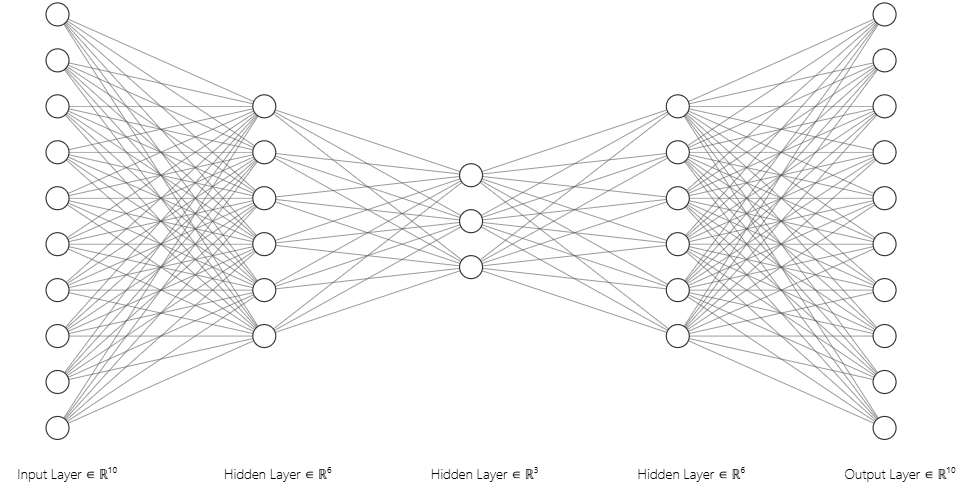

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

## AUTO-ENCODER (the whole autoencoder)
AE = Sequential(name = "Auto-Encoder Architecture")
AE.add(Input(shape=(10,)))             ## [encoder] input layer with # of variables as neurons
AE.add(Dense(6, activation='relu'))    ## [encoder] hidden layer
AE.add(Dense(3, activation='relu'))    ## [encoder-decoder] latent space
AE.add(Dense(6, activation='relu'))    ## [decoder] hidden layer
AE.add(Dense(10, activation='linear')) ## [decoder] output layer

## LOSS FUNCTION: MSE
AE.compile(optimizer='adam', loss='mse')

## SUMMARY
AE.summary()

## FIT
## AE.fit(X, X, epochs = 100, validation_split = 0.2, callbacks = [early_stop])

## PREDICT
## X_reconstructed = AE.predict(X)
## X and X_reconstructed. Say that obs 10 has a huge reconstruction error (likely anomaly)

Model: "Auto-Encoder Architecture"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │            70 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181 (724.00 B)

 Trainable params: 181 (724.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
## what if you want h (encoder NN) and f (decoder) separately

from tensorflow.keras.models import Model ## can combine different neural nets

## ENCODER (h)
encoder = Sequential(name = "Encoder")
encoder.add(Input(shape=(10,)))
encoder.add(Dense(6, activation='relu'))
encoder.add(Dense(3, activation='relu'))  ## latent space

## DECODER (f)
decoder = Sequential(name = "Decoder")
decoder.add(Input(shape=(3,)))
decoder.add(Dense(6, activation='relu'))
decoder.add(Dense(10, activation='linear'))

## Combine the two
AE1 = Model(inputs = encoder.inputs, outputs = decoder(encoder.outputs))

## compile
AE1.compile(optimizer='adam', loss='mse')

## summary
AE1.summary()

## fit
## AE1.fit(X, X, epochs = 100, validation_split = 0.2, callbacks = [early

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Sequential)            │ (None, 10)             │            94 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 181 (724.00 B)

 Trainable params: 181 (724.00 B)

 Non-trainable params: 0 (0.00 B)

---

# 2. Architecture and bottleneck

A simple autoencoder looks like:

**Input → Encoder → Latent Space → Decoder → Reconstruction**

The input and output layers have the same number of variables because the goal is to reconstruct the original input.

## Practice 2A

Suppose a dataset has 12 input variables and an autoencoder uses:

- Input: 12
- Hidden: 8
- Latent: 3
- Hidden: 8
- Output: 12

Answer:

1. What is the bottleneck dimension?
2. Why must the output layer have 12 neurons?


**Your response here:**  
1.  3-dimensional latent space
2.  We are predicting X so we need the same dimension

## Practice 2B: Count parameters

Suppose an autoencoder has:

- Input: 6
- Hidden: 4
- Latent: 2
- Hidden: 4
- Output: 6

How many trainable parameters are there in total?

In [6]:

# TODO
params_input_hidden = 6*4 + 4
params_hidden_latent = 4*2 + 2
params_latent_hidden = 2*4 + 4
params_hidden_output = 4*6 + 6
total_params = params_input_hidden + params_hidden_latent + params_latent_hidden + params_hidden_output

print("Total parameters =", total_params)

Total parameters = 80


---

# 3. Reconstruction error

An autoencoder tries to reproduce the input rather than predict a separate target.

A common loss for numeric inputs is **mean squared error (MSE)**:

$
MSE = \frac{1}{n}\sum_{i=1}^{n}(x_i - \hat{x}_i)^2
$

## Practice 3A

Suppose for one observation:

- original: `[4.0, 2.0, 6.0]`
- reconstructed: `[3.5, 2.2, 5.4]`

Compute the observation-level MSE.

In [7]:
## every obs has p-variables
## the reconstruction error is the MSE value by each row
## example, say that we have p = 3 (sqft, # rooms, dist)
x_true = np.array([4.0, 2.0, 6.0])
x_hat = np.array([3.5, 2.2, 5.4])

# TODO
obs_mse = np.mean((x_true - x_hat)**2) ## an mse by obs

print("Observation MSE =", obs_mse)

## if I have a whole data X
## we need MSE calculated by row (reconstruction error)

Observation MSE = 0.21666666666666656


## Practice 3B

If an observation has a much larger reconstruction error than the others, what might that suggest in an anomaly-detection setting?

**Your response here:**  





---

# 4. Tiny encoder-decoder example by hand

In [8]:

# One observation with 4 features
x = np.array([8.0, 3.0, 6.0, 1.0])

# Encoder: 4 -> 2
W_enc = np.array([
    [0.20, 0.10],
    [0.40, 0.30],
    [0.10, 0.50],
    [0.30, 0.20]
])
b_enc = np.array([0.1, -0.2])

In [9]:
# Decoder: 2 -> 4
W_dec = np.array([
    [0.50, 0.20, 0.30, 0.10],
    [0.10, 0.40, 0.20, 0.30]
])
b_dec = np.array([0.0, 0.1, -0.1, 0.2])

print("Ready.")

Ready.


## Practice 4A

Use the encoder

$
z = xW_{enc} + b_{enc}
$

Compute the 2-dimensional latent vector `z`.

In [16]:
# TODO
z = x.dot(W_enc) + b_enc
print("Latent vector z =", z)

Latent vector z = [3.8 4.7]


In [17]:
# TODO
## add relu activation
def relu(z):
  return np.maximum(0,z)

a = relu(z)
print("Activation a =", a)

Activation a = [3.8 4.7]


## Practice 4B

Use the decoder

$
\hat{x} = aW_{dec} + b_{dec}
$

Compute the reconstructed vector.

In [19]:
# TODO
x_reconstructed = relu(z.dot(W_dec) + b_dec)

print("Reconstructed x =", x_reconstructed)

Reconstructed x = [2.37 2.74 1.98 1.99]


## Practice 4C

Compute the reconstruction MSE between `x` and `x_reconstructed`.

In [20]:
# TODO
tiny_recon_mse = np.mean((x - x_reconstructed)**2)
print("Tiny reconstruction MSE =", tiny_recon_mse)

## this is called the reconstruction error
## we get a reconstruction error per observation
## detection of anomalies is based on the reconstruction error
#### high reconstruction would be a potential fraud


Tiny reconstruction MSE = 12.226249999999999


---

# 5. Example

Let's fit an autoencoder to CRM data with anomalies

In [21]:
df = pd.read_csv('https://raw.githubusercontent.com/martinwg/ISA630/refs/heads/master/data/customer_anomaly_data.csv')


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["is_anomaly"])
y = df["is_anomaly"]

# Scale using only normal training data
scaler = StandardScaler()
X = scaler.fit_transform(X)

print(X.shape,)

(1000, 6)


In [22]:
df.head()

,monthly_spend,website_visits,support_tickets,returns_count,avg_order_value,days_since_last_purchase,is_anomaly
0,565.203223,14.951085,1,0,53.333888,20.223525,0
1,617.922918,19.005798,2,0,77.717876,33.907755,0
2,279.095092,20.933469,4,1,94.870321,16.100165,0
3,431.160559,16.540944,3,0,88.555563,18.015024,0
4,365.042949,20.896457,2,2,82.146916,21.691168,0


In [23]:
df.is_anomaly.value_counts()

,count
is_anomaly,
0,950
1,50


## Practice 5A

Why might an autoencoder be useful on this type of business dataset, even though we do not have a target variable?

**Your response here:**  


In the cases we have very limited number of true (anomalies), we could use an unsupervised technique.

- IsolationForest (great technique)
- Local Outlier Factor
- One-Class SVMs
- Autoencoders (variables) - VAE

Build this structure:

- input dimension = 6
- encoder hidden layer = 3 neurons, ReLU
- latent layer = 2 neurons, linear
- decoder hidden layer = 3 neurons, ReLU
- output layer = 6 neurons, linear

Compile with:
- optimizer = `"adam"`
- loss = `"mse"`

In [28]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

## ENCODER (h)
input = Input(shape=(6,))
hidden1 = Dense(3, activation='relu')(input)
latent = Dense(2, activation='linear')(hidden1) ## if we want to use the latent space (linear)

## DECODER (f)
hidden2 = Dense(3, activation='relu')(latent)
output = Dense(6, activation='linear')(hidden2)

## Combine the two
AE = Model(inputs = input, outputs = output)

## Summary
AE.summary()

## Callback (early stopping)
#### instance
early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=5)

## compile
AE.compile(optimizer= Adam(learning_rate = 0.01), loss='mse')

## fit
AE.fit(X, X, epochs = 100, validation_split = 0.2, callbacks = [early_stop])

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 6)              │            24 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62 (248.00 B)

 Trainable params: 62 (248.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.9593 - val_loss: 0.6692
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5933 - val_loss: 0.4107
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3899 - val_loss: 0.2656
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2614 - val_loss: 0.2053
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2172 - val_loss: 0.1833
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1972 - val_loss: 0.1702
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1892 - val_loss: 0.1648
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1803 - val_loss: 0.1583
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1729 - val_loss: 0.1549
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1671 - val_loss: 0.1453
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1625 - val_loss: 0.1453
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.

## Practice 6C

Plot training loss and validation loss.

Text(0.5, 0, 'Epoch')

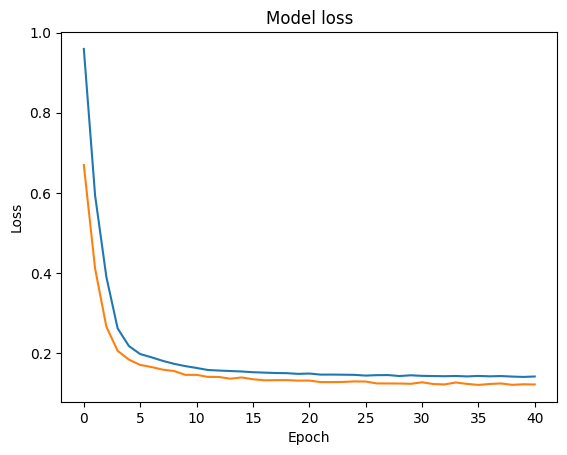

In [29]:
## plot training loss and validation
import matplotlib.pyplot as plt

plt.plot(AE.history.history['loss'])
plt.plot(AE.history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

## Practice 6D

Why does forcing the model through a latent layer with only 2 neurons create compression?

**Your response here:**  

The latent vector z is a function of the original vector x (for each obs), but z is 2-dimensional, whereas x is 6-dimensional. Hopefully, z contains most of the information as x. PCA uses linear combinations, whereas $z = h(x)$ and h is neural network, thus nonlinear.




---

# 7. Latent space and dimension reduction

## Practice 7A

Create an encoder model that maps the original inputs to the latent layer, then compute the latent representation for the test data.

In [30]:
## we can get a scatter of the 2-dimensional z
## scatter plot

# Let's create the encoder network output
### the model is already pre-trained
encoder_model = Model(inputs = input, outputs = latent)

## no need to fit
## predict
X_latent = encoder_model.predict(X)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [32]:
X_latent = pd.DataFrame(X_latent, columns = ['Latent 1', 'Latent 2'])
X_latent.head()

,Latent 1,Latent 2
0,-0.391859,0.331801
1,-0.782618,0.767968
2,-1.421645,0.792156
3,-0.714487,0.419631
4,-1.370458,0.776014


## Practice 7B

Make a scatter plot of the two latent dimensions.

Text(0.5, 1.0, 'Latent Space')

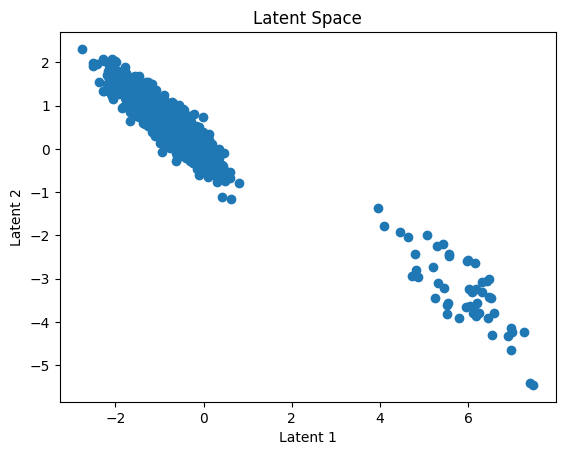

In [33]:
## we can get a scatter of the 2-dimensional z
## scatter plot
import matplotlib.pyplot as plt

plt.scatter(X_latent['Latent 1'], X_latent['Latent 2'])
plt.xlabel('Latent 1')
plt.ylabel('Latent 2')
plt.title('Latent Space')

In [34]:
## generate a plotly scatter plot with is_anomaly label
import plotly.express as px

fig = px.scatter(X_latent, x='Latent 1', y='Latent 2', color=y)
fig.show()

## Practice 7C

How is this related to dimension reduction?

**Your response here:**  


The latent space is reduced dimension. We could use z as the new variable (s)

---

# 8. Reconstruction error as an anomaly score

A common business use of autoencoders is **anomaly detection**.

Idea:
- train on mostly typical observations
- unusual observations reconstruct poorly
- larger reconstruction error can be used as an anomaly score

## Practice 8A

For each observation in `X_test_scaled`, compute

$
\text{MSE}_i = \frac{1}{p}\sum_{j=1}^{p}(x_{ij} - \hat{x}_{ij})^2
$

In [41]:
## reconstruction error is the MSE by obs

#### 1) let's reconstruct the data
X_reconstructed = AE.predict(X)

#### 2) compute MSE by obs
reconstruction_error = np.mean((X - X_reconstructed)**2, axis = 1)
reconstruction_error

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([8.53523763e-02, 1.05214762e-01, 1.73901618e-01, 6.91770087e-02,
       3.17211355e-02, 3.98696943e-02, 1.58471627e-02, 1.43391834e-01,
       1.20915656e-01, 4.61088248e-02, 5.22264412e-02, 7.05583176e-02,
       6.19946600e-02, 8.07940399e-01, 5.94065485e-02, 4.89636765e-02,
       1.53192433e-01, 1.46265055e-01, 1.49715592e-01, 1.96336103e-01,
       5.07876982e-02, 8.01531378e-02, 1.20789530e-01, 7.62878795e-02,
       1.11605433e-01, 1.66008725e-02, 3.63577505e-01, 9.81952811e-01,
       6.10472689e-02, 1.44521158e-01, 1.98049418e-01, 3.52336240e-02,
       7.45730772e-02, 7.43983189e-02, 1.59291299e-02, 3.69135408e-02,
       3.13361867e-02, 2.59566543e-01, 6.67019345e-02, 1.65528861e-01,
       1.65521804e-01, 1.10486026e-01, 3.86049619e-02, 1.07662955e+00,
       1.16860111e-01, 2.45260830e-01, 1.04268986e-01, 6.13037763e-02,
       5.82591937e-02, 1.89626454e-01, 1.17096424e-01, 5.49739758e-02,
       5.64916846e-02, 1.69012177e-01, 8.54022669e-02, 1.19201723e-02,
      

## Practice 8B

Display the 10 observations with the highest reconstruction error.

In [42]:
##
df['reconstruction_error'] = reconstruction_error
df.sort_values(by = 'reconstruction_error', ascending = False).head(10)

,monthly_spend,website_visits,support_tickets,returns_count,avg_order_value,days_since_last_purchase,is_anomaly,reconstruction_error
605,1623.782617,1.795667,8,9,594.411171,103.729184,1,2.068507
508,1568.539351,4.488818,15,6,570.105857,73.572691,1,1.914682
917,939.514152,1.899547,17,12,235.682624,166.802268,1,1.892099
720,1099.010937,2.541882,19,13,588.341679,90.222403,1,1.829302
639,955.355163,2.558630,18,6,307.796020,154.760834,1,1.752814
86,1071.411297,4.130606,18,8,252.336945,66.688263,1,1.455926
107,1146.835665,1.632963,18,7,578.990894,153.276258,1,1.377317
767,1053.850404,1.997181,12,7,507.359972,61.793997,1,1.335658
133,1519.108781,1.190071,11,7,572.140471,120.452813,1,1.332857
630,946.200934,3.966412,17,13,297.085995,148.656606,1,1.254681


## Practice 8C

Give one reason why a large reconstruction error might flag an unusual customer profile.

**Your response here:**  

A large reconstruction can point to large anomalies because the auto-encoder had trouble predicting the observation so it does not behave as the rest.



In [43]:
## The top reconstruction errors - Let's select the top 100 obs with largest reconstruction
#### how many anomalies do we catch
df_100 = df.sort_values(by = 'reconstruction_error', ascending = False).head(100)

## top 1 anomalies
df_100.is_anomaly.value_counts()

,count
is_anomaly,
0,56
1,44


In [46]:
## metrics
### Recall

df_100.is_anomaly.sum() / df.is_anomaly.sum()

np.float64(0.88)